In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import fftconvolve
from scipy.optimize import curve_fit
from scipy.stats import norm
import functions as ft
import re
from natsort import natsorted
from glob import glob
import matplotlibcolors as matplotlibcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
plt.style.use('matplotlibrc')

%matplotlib widget

In [2]:
kid = 5
pread = 113
file_type = 'vis'
pw = 1500
pw_offset = 100
filter_type = 'exp'
lifetime = 236
tqp = [200, 600]
iterate = 0

dir_on = r"D:\Data\LT218Chip1_BF_20240116_MIR18_5\KID5_all_temps\180K"
dir_off = r"D:\Data\LT218Chip1_BF_20240116_MIR18_5\KID5_all_temps\142K"
chuncksize = 40
nr_chuncks = 1
mph = np.array([5, 40])
mpp = mph[0]


In [3]:
dir = dir_on
info_files = natsorted(glob(dir + '\*TDvis0*_info.dat'))
kid_table = np.zeros((27, 2))
kid_table[:, 0] = np.arange(27)
f0s = np.load(r'D:\Data\LT218_MUX\LT218_27f0s_from_VNA.npy')
for file in info_files:
    id = int(re.findall('KID\d+', file)[0][3:])
    f0_meas = ft.get_info(file)[0]
    id_main = np.argmin(np.absolute(f0_meas - f0s))
    if kid_table[id_main,1] != 0:
        print(f"Warning: KID{id} with f0 {f0_meas} already assigned to KID {kid_table[id_main,1]} with f0 {f0s[id_main]}")
    kid_table[id_main,1] = id
    # print(id_main, id)
# kid_table[25,1] = 23
kid_table

array([[ 0.,  0.],
       [ 1.,  0.],
       [ 2.,  0.],
       [ 3.,  0.],
       [ 4.,  0.],
       [ 5.,  0.],
       [ 6.,  0.],
       [ 7.,  5.],
       [ 8.,  0.],
       [ 9.,  0.],
       [10.,  0.],
       [11.,  0.],
       [12.,  0.],
       [13.,  0.],
       [14.,  0.],
       [15.,  0.],
       [16.,  0.],
       [17.,  0.],
       [18.,  0.],
       [19.,  0.],
       [20.,  0.],
       [21.,  0.],
       [22.,  0.],
       [23.,  0.],
       [24.,  0.],
       [25.,  0.],
       [26.,  0.]])

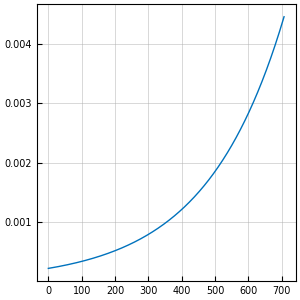

In [4]:
pulse_files, info_files = ft.get_files(dir_on, kid, pread, type=file_type)
nr_files = len(pulse_files)
f0, Q, Qc, Qi, S21_min, dt, T = ft.get_info(info_files[0])
sff = 1 / dt / 1e6
sw = int(lifetime * sff)
exp_filter = ft.get_window(filter_type, sw)
fig, ax = plt.subplots(figsize=(3,3),constrained_layout=True)
ax.plot(exp_filter)

In [5]:
amp, phase, _ = ft.get_data(pulse_files[:chuncksize])
signal = ft.coord_transformation(phase, amp, coord='circle', response='phase')

In [6]:
std = ft.get_sigma(signal, exp_filter)
ph = mph*std
pp = mpp*std
locs, props = ft.find_pks(signal, ph[0], pp, exp_filter)
too_high_chunck = props['peak_heights'] >= ph[1]
args = np.argwhere(~too_high_chunck).flatten()
pulses, single_idx = ft.get_single_pulses(signal, locs, pw, pw_offset, args)
pulse_template = np.mean(pulses, axis=0)

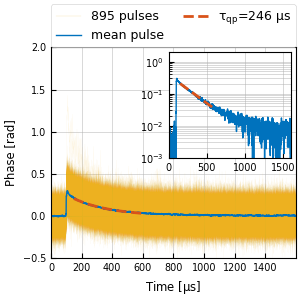

In [7]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(3,3))
t = np.arange(0, pw+pw_offset, 1)
ax.plot(t, pulses.T, alpha=.2, lw=.1, c='y', label='_nolegend_')
ax.plot(t, pulses[0], lw=.1, c='y', label='%d pulses' % len(pulses))
ax.plot(t, pulse_template, label='mean pulse')
ax.set_xlim([t[0], t[-1]])
ax.set_ylim([-.5, 2])
ax.set_xlabel('Time [$\mu$s]')
ax.set_ylabel('Phase [rad]')
_ = ax.legend()

fit_tqp = [150,600]    
tqp, _, popt = ft.fit_decaytime(pulse_template, fit_tqp)
tqp /= sff
tqp_x = np.linspace(fit_tqp[0]/sff, fit_tqp[1]/sff, int((fit_tqp[1] - fit_tqp[0])))
fit_x = np.arange(len(tqp_x))
tqp_y = ft.exp_decay(fit_x, *popt)
ax.plot(tqp_x, tqp_y, ls='--', lw=2, label='$\\tau_{qp}$=%d $\mu$s' % tqp, zorder=3)
ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
        ncols=2, mode="expand", borderaxespad=0., fontsize=9)
# BEGIN: Add inset with semilogy axes

ax_inset = inset_axes(ax, width="50%", height="50%", loc='upper right')
ax_inset.plot(t, pulse_template, label='mean pulse')
ax_inset.set_xlim([t[0], t[-1]])
ax_inset.set_ylim([1e-3, 2])
ax_inset.set_yscale('log')
# ax_inset.set_xlabel('Time [$\mu$s]')
# ax_inset.set_ylabel('Phase [rad]')
ax_inset.plot(tqp_x, tqp_y, ls='--', lw=2, label='$\\tau_{qp}$=%d $\mu$s' % tqp, zorder=3)
# END: Add inset with semilogy axes

In [8]:
noise_files, _ = ft.get_files(dir_on, kid, pread, type=file_type)
amp, phase, _ = ft.get_data(noise_files[:chuncksize])
noise = ft.coord_transformation(phase, amp, coord='circle', response='phase')

In [9]:
std = ft.get_sigma(noise, exp_filter)
ph = 4*std
pp = ph
noise_locs, _ = ft.find_pks(noise, ph, pp, exp_filter)
noises = ft.get_single_noises(noise, noise_locs, pw+pw_offset)
_, noise_psd = ft.get_avg_psd(noises, pw+pw_offset, sff, exclude_dc=False, onesided=False)

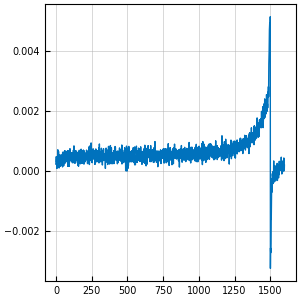

In [10]:
# def opt_filter(mean_pulse, noise_psd, exclude_dc=True):      
#     """
#     optimal_filter computes the optimal filter that needs to be uploaded to the mux
#     :param norm_pulse_fft:  numpy.ndarray, 1D complex array of pulse model
#     :param noise_psd:       numpy.ndarray, 1D complex array of noise model
#     :param exclude_dc:      bool, whether to exclude the DC value of the fft
#     :return filter:         numpy.ndarray, 1D comlex array of normalised optimal filter
#     """
#     norm_pulse = mean_pulse / np.amax(mean_pulse)
#     norm_pulse_fft = fft(norm_pulse)
#     filter = norm_pulse_fft.conj()/noise_psd
#     return ifft(filter)

opt_filter = ft.opt_filter(pulse_template, noise_psd, exclude_dc=False).real
opt_filter /= np.sum(opt_filter)
fig, ax = plt.subplots(constrained_layout=True, figsize=(3,3))
ax.plot(opt_filter)

(-0.2, 0.5)

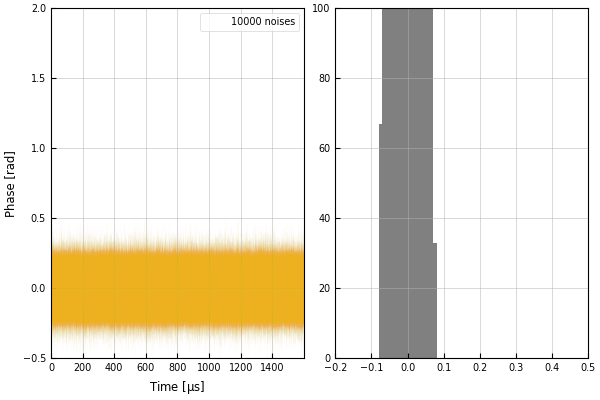

In [11]:
fig, axes = plt.subplot_mosaic('ab', constrained_layout=True, figsize=(6,4))
ax = axes['a']
t = np.arange(0, pw+pw_offset, 1)
ax.plot(t, noises[::10].T, alpha=.1, lw=.1, c='y')
ax.plot(t, noises[0], alpha=.1, lw=.1, c='y', label='%d noises' % len(noises))
# ax.plot(t, pulse_template)
ax.set_xlim([t[0], t[-1]])
ax.set_ylim([-.5, 2])
ax.set_xlabel('Time [$\mu$s]')
ax.set_ylabel('Phase [rad]')
ax.legend(loc='upper right')
ax = axes['b']
binsize = 0.01
bins=np.arange(-.5, 2, binsize)
_ = ax.hist(fftconvolve(noises.flatten(), opt_filter, mode='valid'), bins=bins, facecolor='gray', label='0 $\sigma$')
ax.set_ylim([0,100])
ax.set_xlim([-.2,.5])

In [12]:
def get_pulses(pulse_files, ph, pp, pw, pw_offset, chuncksize, nr_chuncks, window):
    if nr_chuncks:
        nr_req_files = np.amin((chuncksize * nr_chuncks, nr_files))
    else:
        nr_req_files = nr_files
    analysed_files = 0
    pulses = []
    single_idx = []
    too_high_idx = []
    single_locs = []
    while analysed_files < nr_req_files:
        if analysed_files + chuncksize > nr_files:
            chuncksize = nr_files - analysed_files
        amp, phase, _ = ft.get_data(pulse_files[analysed_files:analysed_files+chuncksize])
        signal = ft.coord_transformation(phase, amp, coord='circle', response='phase')
        len_file = int(len(signal) / chuncksize)
        locs, props = ft.find_pks(signal, ph, pp, window)
        # too_high_chunck = props['peak_heights'] >= ph[1]
        args = np.argwhere(~too_high_chunck).flatten()
        args = np.arange(len(locs), dtype=int)
        pulses_chunck, single_idx_chunck = ft.get_single_pulses(signal, locs, pw, pw_offset, args)
        if len(pulses_chunck):
            pulses.append(pulses_chunck)
            single_idx.append(single_idx_chunck)
            too_high_idx.append(too_high_chunck)
            single_locs.append(locs[single_idx_chunck] + len_file*analysed_files)
        analysed_files += chuncksize
        print('Analysed %d out of %d files' % (analysed_files, nr_req_files), end='\r')
    single_idx = np.hstack(single_idx)
    pulses = np.vstack(pulses)
    too_high_idx = np.hstack(too_high_idx)
    single_locs = np.hstack(single_locs)
    return pulses, single_idx, too_high_idx, single_locs


In [13]:
std = ft.get_sigma(noise, exp_filter)
nr_stds = [5]
H_opts = []
nr_chuncks = [None, None, None, None]
for i, nr_std in enumerate(nr_stds):
    ph = nr_std * std
    pp = nr_std * std
    pulses, _, _, _ = get_pulses(pulse_files, ph, pp, pw, pw_offset, 40, nr_chuncks[i], exp_filter)
    H_opt, R_sn, _, _ = ft.optimal_filter(pulses, pulse_template, sff*1e6, 1, noise_psd)
    H_opts.append(H_opt)

2.72038780411435


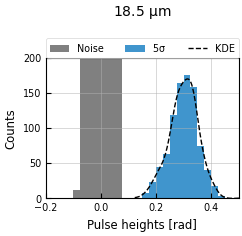

In [14]:
fig, axes = plt.subplot_mosaic('a', constrained_layout=True, figsize=(18.5/3/2.54,6/2.54))
ax = axes['a']
binsize = 0.025
bins=np.arange(-.5, 2, binsize)
ax.hist(fftconvolve(noises.flatten(), opt_filter, mode='valid'), bins=bins, facecolor='gray', label='Noise', zorder=0)
colors = ['b', 'y', 'o', 'p'] 
for i, H_opt in enumerate(H_opts):
    _ = ax.hist(H_opt, bins=bins, facecolor=colors[i],alpha=.75, label='%d$\sigma$' % (nr_stds[i]), zorder=i)

ax.set_ylim([0, 200])
ax.set_xlim([-.2,.5])
ax.set_ylabel('Counts')
ax.set_xlabel('Pulse heights [rad]')
H_opt = H_opts[-1]

ax = axes['a']
ax.set_title('18.5 $\mu$m', pad=30, fontsize=10)
R_opt, pdf_y, pdf_x, _, _ = ft.resolving_power(H_opt, binsize)
print(R_opt)
ax.plot(pdf_x, pdf_y, c='k', ls='--', label='KDE', lw=1, zorder=5)
ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
        ncols=3, mode="expand", borderaxespad=0.)
# plt.savefig('resolving power 185umv3.pdf')

In [ ]:
fig, axes = plt.subplot_mosaic('a', constrained_layout=True, figsize=(18.5/3/2.54,6/2.54))
ax = axes['a']
ax.plot(np.mean(pulses, axis=0), label='mean pulse', c='b')


2.7165621546457106
2.716540324008259
2.714818770705101
2.716511166624381
2.713924151992991
2.716477412320337
2.7112249441645435
2.716452035513383
2.719806612238455
2.71467881221731
2.71649182033372
2.716391828968041
2.717158427983192
2.7213192976321916
2.7152558313262443
2.7163115684026713
2.7081477178832203
2.710832773206524
2.706342513415004
2.716268251474907
2.72038780411435
2.7193217157088427
2.7137770406248727
2.7256387673067004
2.7108469433968096
2.715857265682484
2.7173571705885533
2.716140556365765
2.710279936698416
2.7007619270785646
2.7192717131848854
2.70441008654645
2.7188922115682117
2.696947941689346
2.7073172842016393
2.7159953158446273
2.7204274404036544
2.724612741806966
2.72794734651029
2.727388803285195
2.726273226795165
2.725207660439571
2.7204583817954187
2.715873287377085
2.707087121458771
2.6973433488903096
2.7288571197392715
2.7182886330978477
2.7024500917358636
2.7332507836334896
2.7172204666877486
2.7002177057277974
2.728630866662937
2.707044373442157
2.735171

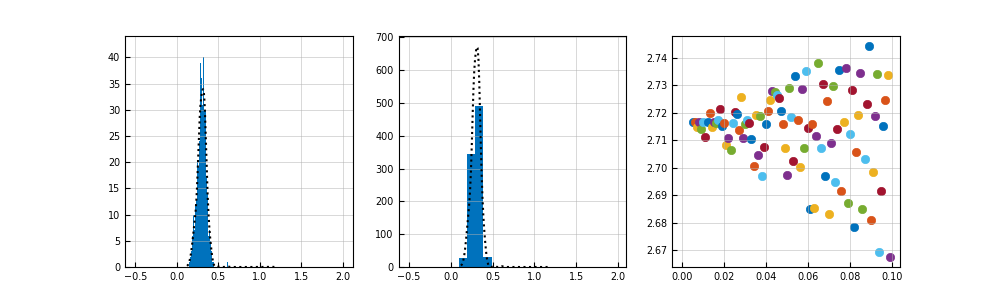

In [48]:
def single_gaussian(x, mu1, sigma1, A1):
    return A1 * norm.pdf(x, mu1, sigma1)

binsizes = np.arange(0.005, 0.1, 0.001)
Rs = []
fig, axes = plt.subplot_mosaic('abc', figsize=(10,3))
for i, binsize  in enumerate(binsizes):
    bins=np.arange(-.5, 2, binsize)
    R, pdf_y, pdf_x, _, _ = ft.resolving_power(H_opt, binsize)
    Rs.append(R)
    if i==0:
        ax = axes['a']
        ax.hist(H_opt, bins=bins, zorder=0)
        ax.plot(pdf_x, pdf_y, c='k', ls=':', label='KDE', lw=1.5)
    if i==len(binsizes)-1:
        ax = axes['b']
        ax.hist(H_opt, bins=bins, zorder=0)
        ax.plot(pdf_x, pdf_y, c='k', ls=':', label='KDE', lw=1.5)
    print(R)
    ax = axes['c']
    ax.scatter(binsize, R)
print(np.mean(Rs), np.sqrt(1/12*(np.amax(Rs)-np.amin(Rs))**2), np.std(Rs))
axes['c'].plot(np.mean(Rs))
axes['c'].plot(np.mean(Rs))